# Regularized Regression for Return Prediction

**Chapter 11 | Section 11.2**

**Docker image**: `ml4t`

This notebook compares OLS, Ridge (L2), LASSO (L1), and Elastic Net regression
for predicting 21-day forward returns on the ETF universe. Every model is fitted
on the same walk-forward folds, declared once in `setup.yaml` and loaded by
`generate_cv_splits`, so that any difference between them comes from the
penalty and not from the split.

**Learning objectives**

- Understand the bias-variance tradeoff in regularized regression
- Compare Ridge, LASSO, and Elastic Net on real financial features
- Analyze regularization paths and LASSO feature selection
- Evaluate predictive performance via Information Coefficient (IC)

**Book reference**

Section 11.2 ("Regularized Regression"). The next notebook,
`03_logistic_classification`, applies the same regularization toolkit to the
direction-prediction task; `04_nested_cv_hpo` extends the alpha sweep into
nested cross-validation.

**Prerequisites**

- Working knowledge of OLS and the bias-variance tradeoff.
- Conceptual exposure to L1, L2, and Elastic-Net penalties.
- ETF case-study features at `case_studies/etfs/features/financial.parquet`
  (Ch8) and labels at `case_studies/etfs/labels/fwd_ret_21d.parquet` (Ch7).

**Downstream**: Ch12 (gradient boosting), Ch16-17 (backtesting + portfolio).

## Setup

In [1]:
"""Regularized Regression for Return Prediction - compare Ridge, LASSO, and Elastic Net via walk-forward CV."""

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.colors import ListedColormap
from scipy.stats import spearmanr
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
    SGDRegressor,
    lasso_path,
)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from utils.cv_splits import generate_cv_splits
from utils.modeling import cross_sectional_ic_mean
from utils.paths import get_case_study_dir, get_chapter_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt

In [2]:
SEED = 42
MAX_SYMBOLS = 0
RETRAIN = False

In [3]:
RANDOM_SEED = SEED
set_global_seeds(SEED)

## Load Features and Labels

We load pre-computed ETF features from Ch8 and 21-day forward return labels
from Ch7. No synthetic fallback - if files are missing, run upstream notebooks.

In [4]:
CASE_DIR = get_case_study_dir("etfs")
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"
LABELS_PATH = CASE_DIR / "labels" / "fwd_ret_21d.parquet"

assert FEATURES_PATH.exists(), (
    f"Features not found: {FEATURES_PATH}\nRun the Ch8 ETF features notebook first."
)
assert LABELS_PATH.exists(), (
    f"Labels not found: {LABELS_PATH}\nRun the Ch7 ETF labels notebook first."
)

features_df = pl.read_parquet(FEATURES_PATH).with_columns(pl.col("timestamp").cast(pl.Date))
labels_df = pl.read_parquet(LABELS_PATH).with_columns(pl.col("timestamp").cast(pl.Date))

In [5]:
TARGET_COL = "fwd_ret_21d"
ASSET_COL = "symbol"

df = features_df.join(labels_df, on=["timestamp", ASSET_COL], how="inner")

META_COLS = {"timestamp", ASSET_COL, TARGET_COL}
FEATURE_COLS = sorted(c for c in df.columns if c not in META_COLS)

# Drop features that are entirely null (can happen with reduced test universes)
all_null = [c for c in FEATURE_COLS if df[c].null_count() == df.height]
if all_null:
    print(f"Dropping {len(all_null)} all-null features: {all_null}")
    df = df.drop(all_null)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_null]

# Replace inf/NaN with null, then drop all nulls
df = df.with_columns(
    [
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(None)
        .otherwise(pl.col(c))
        .alias(c)
        for c in FEATURE_COLS
    ]
)
df = df.drop_nulls(subset=FEATURE_COLS + [TARGET_COL]).sort(["timestamp", ASSET_COL])

if MAX_SYMBOLS > 0:
    assets = df[ASSET_COL].unique().sort().head(MAX_SYMBOLS).to_list()
    df = df.filter(pl.col(ASSET_COL).is_in(assets))

print(f"Shape: {df.height:,} rows x {len(FEATURE_COLS)} features")
print(f"Assets: {df[ASSET_COL].n_unique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Shape: 402,446 rows x 57 features
Assets: 99
Date range: 2007-01-04 to 2025-12-01


## Walk-Forward Cross-Validation Setup

We load the canonical walk-forward splits from `setup.yaml` via
`generate_cv_splits`: rolling train/validation windows with purge gap.
This ensures consistency across all Ch11 notebooks and case studies.

In [6]:
splits = generate_cv_splits(df, case_study_id="etfs", label_buffer="21D", date_col="timestamp")

features_array = df.select(FEATURE_COLS).to_numpy()
target_array = df[TARGET_COL].to_numpy()
dates_np = df["timestamp"].to_numpy()
symbols_np = df[ASSET_COL].to_numpy()

cv_splits = []
for s in splits:
    tr_start, tr_end = np.datetime64(s["train_start"]), np.datetime64(s["train_end"])
    te_start, te_end = np.datetime64(s["val_start"]), np.datetime64(s["val_end"])
    train_idx = np.where((dates_np >= tr_start) & (dates_np <= tr_end))[0]
    test_idx = np.where((dates_np >= te_start) & (dates_np <= te_end))[0]
    if len(train_idx) > 0 and len(test_idx) > 0:
        cv_splits.append((train_idx, test_idx))

train_sizes = [len(tr) for tr, _ in cv_splits]
test_sizes = [len(te) for _, te in cv_splits]
if cv_splits:
    print(
        f"{len(cv_splits)} walk-forward folds - train size "
        f"{min(train_sizes):,}–{max(train_sizes):,}, test size "
        f"{min(test_sizes):,}–{max(test_sizes):,}"
    )
else:
    print("0 walk-forward folds - every candidate split failed the train/test size gate")

8 walk-forward folds - train size 165,105–228,787, test size 22,174–24,192


## Helper Functions

Every model below is scored the same way: rank the cross-section on each
validation date, correlate that ranking with the realized forward return, and
average over the dates where that correlation exists. Two kinds of date have
none. A date with fewer symbols quoting than the minimum cross-section is not
scored at all. A date where the model gives every symbol the same prediction
has no ranking to correlate, so its Spearman coefficient is undefined. Strong
regularization produces exactly that: at a high enough alpha every coefficient
is zero and the model predicts one constant for everything.

`utils.modeling.cross_sectional_ic_mean` is the shared implementation, and
dropping those dates is the part worth knowing about - a single undefined date
left in the series turns the average of the whole series into NaN.

In [7]:
def evaluate_predictions(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dates: np.ndarray,
    symbols: np.ndarray,
) -> dict:
    """Compute mean cross-sectional IC, RMSE, and R-squared on a test fold."""
    ic = cross_sectional_ic_mean(y_true, y_pred, dates, symbols)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"ic": ic, "rmse": rmse, "r2": r2}

### Winsorization

Clipping features at the 1st and 99th percentiles (computed on training data)
limits the influence of extreme observations on standardization. Without
winsorization, a single outlier can inflate $\sigma_j$ and compress all other
observations toward zero. The percentile bounds are fitted on training data
only to prevent look-ahead bias.

In [8]:
def winsorize_train_test(
    X_train: np.ndarray, X_test: np.ndarray, lower: float = 1.0, upper: float = 99.0
) -> tuple[np.ndarray, np.ndarray]:
    """Clip features at training-set percentiles to limit outlier influence."""
    lo = np.percentile(X_train, lower, axis=0)
    hi = np.percentile(X_train, upper, axis=0)
    return np.clip(X_train, lo, hi), np.clip(X_test, lo, hi)

### Walk-Forward Cross-Validation
Run walk-forward CV with per-fold winsorization and standardization.

In [9]:
def cross_validate(
    model_class, model_params: dict
) -> tuple[list[dict], list[np.ndarray], list[dict]]:
    """Run walk-forward CV on pre-computed splits.

    Preprocessing per fold: winsorize (1st/99th on train) → standardize.
    Returns per-fold metrics, coefficient arrays, and (model, scaler) pairs.
    """
    results, coefficients, fold_models = [], [], []

    for i, (train_idx, test_idx) in enumerate(cv_splits):
        X_tr, X_te = features_array[train_idx], features_array[test_idx]
        y_tr, y_te = target_array[train_idx], target_array[test_idx]

        # Winsorize before standardizing (percentiles fitted on training data)
        X_tr, X_te = winsorize_train_test(X_tr, X_te)

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        model = model_class(**model_params)
        model.fit(X_tr_s, y_tr)

        y_pred = model.predict(X_te_s)
        metrics = evaluate_predictions(y_te, y_pred, dates_np[test_idx], symbols_np[test_idx])
        metrics["fold"] = i + 1
        metrics["train_size"] = len(X_tr)
        metrics["test_size"] = len(X_te)
        results.append(metrics)

        if hasattr(model, "coef_"):
            coefficients.append(model.coef_.ravel().copy())
        fold_models.append({"model": model, "scaler": scaler})

    return results, coefficients, fold_models

## Model Cache

Training results (including fitted models and scalers) are cached to disk.
Set `RETRAIN = True` to force retraining.

In [10]:
MODELS_DIR = get_chapter_dir(11) / "models" / "02_regularization_paths"
RESULTS_PATH = MODELS_DIR / "cv_results.joblib"
NEED_TRAINING = RETRAIN or not RESULTS_PATH.exists()

if not NEED_TRAINING:
    _cached = joblib.load(RESULTS_PATH)
    ols_df = _cached["ols_df"]
    ols_coeffs = _cached["ols_coeffs"]
    ols_models = _cached["ols_models"]
    ridge_all = _cached["ridge_all"]
    ridge_summary = _cached["ridge_summary"]
    best_ridge_alpha = _cached["best_ridge_alpha"]
    RIDGE_ALPHAS = _cached["RIDGE_ALPHAS"]
    lasso_all = _cached["lasso_all"]
    lasso_summary = _cached["lasso_summary"]
    best_lasso_alpha = _cached["best_lasso_alpha"]
    alpha_max = _cached["alpha_max"]
    LASSO_ALPHAS = _cached["LASSO_ALPHAS"]
    en_all = _cached["en_all"]
    en_summary = _cached["en_summary"]
    best_en_key = _cached.get("best_en_key", en_summary.row(0, named=True)["params"])
    path_alphas = _cached["path_alphas"]
    path_coefs = _cached["path_coefs"]
    loss_comparison = _cached.get("loss_comparison")
    del _cached
    print(
        f"  Ridge: {len(ridge_all)} alphas | LASSO: {len(lasso_all)} alphas | EN: {len(en_all)} ratios"
    )
else:
    print("Training models (RETRAIN=True or no cache found)...")

  Ridge: 23 alphas | LASSO: 10 alphas | EN: 3 ratios


## OLS Baseline

Ordinary Least Squares provides the unregularized reference point every
penalty below is measured against. It minimizes squared error on the training
fold with nothing holding its coefficients back, which on this many correlated
features and this little signal is the condition overfitting needs.

In [11]:
if NEED_TRAINING:
    res, coeffs, models = cross_validate(LinearRegression, {})
    ols_df = pl.DataFrame(res)
    ols_coeffs = coeffs
    ols_models = models

In [12]:
print(f"OLS - Mean IC: {ols_df['ic'].mean():.4f} (std: {ols_df['ic'].std():.4f})")
ols_df.select("fold", "ic", "rmse", "r2", "train_size", "test_size")

OLS - Mean IC: 0.0231 (std: 0.0547)


fold,ic,rmse,r2,train_size,test_size
i64,f64,f64,f64,i64,i64
1,0.007624,0.055466,-0.184454,165105,22184
2,0.016477,0.040422,-0.451786,187331,23912
3,-0.021334,0.047917,-0.07616,199440,24189
4,-0.0282,0.047055,-0.229952,208543,24192
5,0.044843,0.098523,0.045556,214378,23942
6,0.129256,0.047007,0.024899,220443,23940
7,0.064235,0.075062,-0.027669,224752,23940
8,-0.028225,0.054918,-0.105761,228787,22174


## Ridge Regression (L2)

Ridge shrinks all coefficients towards zero without setting any exactly to zero.
We sweep 23 log-spaced $\alpha$ values from $10^{-2}$ to $10^{9}$, covering the
full transition from under-regularized (indistinguishable from OLS) through the
optimal range to over-regularized (coefficients crushed to near zero).

In [13]:
if NEED_TRAINING:
    RIDGE_ALPHAS = np.logspace(-2, 9, 23)
    ridge_all = {}

    for alpha in RIDGE_ALPHAS:
        res, coeffs, models = cross_validate(Ridge, {"alpha": alpha, "random_state": RANDOM_SEED})
        ridge_all[alpha] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "models": models,
        }

    ridge_summary = pl.DataFrame(
        [
            {"alpha": a, "mean_ic": d["results"]["ic"].mean(), "std_ic": d["results"]["ic"].std()}
            for a, d in ridge_all.items()
        ]
    ).sort("mean_ic", descending=True)

    best_ridge_alpha = ridge_summary.row(0, named=True)["alpha"]

In [14]:
print(
    f"Best Ridge alpha: {best_ridge_alpha:.2f}  IC: {ridge_summary.filter(pl.col('alpha') == best_ridge_alpha)['mean_ic'].item():.4f}"
)
ridge_summary

Best Ridge alpha: 31622.78  IC: 0.0481


alpha,mean_ic,std_ic
f64,f64,f64
31622.776602,0.048102,0.055867
100000.0,0.047237,0.045696
1e6,0.046553,0.034268
316227.766017,0.046528,0.035542
10000.0,0.045285,0.058945
…,…,…
1.0,0.02311,0.054727
0.316228,0.023088,0.054719
0.01,0.023086,0.054716


Read the sweep for its shape rather than its maximum. A flat stretch means the
penalty is doing little; a rise means shrinkage is buying more in variance than
it costs in bias; a fall at the far end means the coefficients have been
crushed to the point where the model has stopped ranking. Where the turn comes
is a property of how much signal the features carry, which is why a sweep this
wide is worth running on a new dataset rather than reusing an alpha from an
old one.

### Sample Weighting: Recency via Exponential Decay

Section 11.2 discusses sample weighting as a way to emphasize recent data
without discarding older observations. The weight decays exponentially with
age, $w_t = e^{-\lambda(T - t)}$, so the newest observation counts fully and
older ones fade smoothly rather than falling off a cliff at a cutoff date.

Age has to be measured in trading sessions, not in rows. This is a panel: every
session contributes one row per symbol, so about a hundred rows share each
date. Counting age down the rows would decay the weight roughly a hundred times
faster than intended, and would hand two symbols quoting on the same day
different weights for no reason. Each row is therefore aged by the session it
belongs to.

The decay rate is set below as a half-life: the number of sessions after which
an observation counts half as much as today's. The effective sample size turns
that rate into the quantity that decides whether the trade is worth making,
which is how many rows the fit is effectively left with. It is Kish's,

$$N_{\text{eff}} = \frac{\bigl(\sum w_t\bigr)^2}{\sum w_t^2}$$

rather than $\sum w_t$, because only this form is unchanged when every weight
is multiplied by a constant. That matters here: the weights are rescaled to
mean one before fitting, so $\sum w_t$ would answer for a vector the fit does
not use and would report the full sample every time. We compare a single Ridge fit with and without weighting
on the last fold.

In [15]:
if NEED_TRAINING:
    # Last fold for demonstration
    tr_last, te_last = cv_splits[-1]
    X_tr_raw, X_te_raw = features_array[tr_last], features_array[te_last]
    X_tr_raw, X_te_raw = winsorize_train_test(X_tr_raw, X_te_raw)
    scaler_sw = StandardScaler()
    X_tr_sw = scaler_sw.fit_transform(X_tr_raw)
    X_te_sw = scaler_sw.transform(X_te_raw)
    y_tr_sw = target_array[tr_last]
    y_te_sw = target_array[te_last]

    # Exponential recency weights aged in sessions: w_t = exp(-lambda * (T - t)),
    # so every row quoting on a session shares that session's weight.
    HALF_LIFE_SESSIONS = 252  # one trading year: a row that old counts half
    n_train_sw = len(y_tr_sw)
    train_dates_sw = dates_np[tr_last]
    train_sessions_sw = np.unique(train_dates_sw)
    age_in_sessions = (len(train_sessions_sw) - 1) - np.searchsorted(
        train_sessions_sw, train_dates_sw
    )
    lam = np.log(2.0) / HALF_LIFE_SESSIONS
    weights = np.exp(-lam * age_in_sessions)
    # Kish, not weights.sum(): the rescaling below multiplies every weight by a
    # constant, which leaves this unchanged and would send a plain sum to n_train.
    n_eff_sw = float(weights.sum() ** 2 / (weights**2).sum())
    # Normalized to mean one before fitting. sklearn scales rows by sqrt(w) without
    # renormalizing, so weights averaging well below one would raise alpha's weight against
    # the data term and the IC gap below would measure that rather than the recency bet.
    weights = weights * (n_train_sw / weights.sum())

    dates_te_sw = dates_np[te_last]
    symbols_te_sw = symbols_np[te_last]

    # Unweighted Ridge
    ridge_uw = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_SEED)
    ridge_uw.fit(X_tr_sw, y_tr_sw)
    ic_uw = cross_sectional_ic_mean(y_te_sw, ridge_uw.predict(X_te_sw), dates_te_sw, symbols_te_sw)

    # Weighted Ridge
    ridge_w = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_SEED)
    ridge_w.fit(X_tr_sw, y_tr_sw, sample_weight=weights)
    ic_w = cross_sectional_ic_mean(y_te_sw, ridge_w.predict(X_te_sw), dates_te_sw, symbols_te_sw)

    # Store for cache
    sample_weight_results = {
        "n_train": n_train_sw,
        "n_sessions": len(train_sessions_sw),
        "half_life": HALF_LIFE_SESSIONS,
        "n_eff": n_eff_sw,
        "ic_uw": ic_uw,
        "ic_w": ic_w,
        # Stamps which formula produced n_eff. A cache written before the Kish change
        # carries every other key with a plain sum-of-weights value, so key presence alone
        # cannot tell the two apart and a stale cache would be read as this notebook's.
        "n_eff_kind": "kish",
    }

In [16]:
if not NEED_TRAINING:
    sample_weight_results = joblib.load(RESULTS_PATH).get("sample_weight_results", {})
    # A cache written before n_sessions and half_life were recorded would KeyError
    # below. Treat it as absent so the reader gets the RETRAIN message instead.
    if (
        not sample_weight_results.keys()
        >= {"n_train", "n_sessions", "half_life", "n_eff", "ic_uw", "ic_w"}
        or sample_weight_results.get("n_eff_kind") != "kish"
    ):
        sample_weight_results = {}

if sample_weight_results:
    print(f"Training rows: {sample_weight_results['n_train']:,}")
    print(f"Training sessions: {sample_weight_results['n_sessions']:,}")
    print(f"Weight half-life: {sample_weight_results['half_life']} sessions")
    print(
        f"Effective sample size: {sample_weight_results['n_eff']:,.0f} rows "
        f"({sample_weight_results['n_eff'] / sample_weight_results['n_train']:.0%} of the fold)"
    )
    print(f"IC unweighted: {sample_weight_results['ic_uw']:.4f}")
    print(f"IC weighted:   {sample_weight_results['ic_w']:.4f}")
else:
    print("Sample weighting results not available - set RETRAIN=True to generate them.")

Training rows: 228,787
Training sessions: 2,496
Weight half-life: 252 sessions
Effective sample size: 68,902 rows (30% of the fold)
IC unweighted: 0.0028
IC weighted:   -0.0084


Compare the two ICs printed above. Recency weighting is a bet that the recent
past resembles the near future more than the distant past does, and the
effective sample size says what the bet costs: the decay leaves the fit with
the equivalent of a fraction of its training rows. Where the bet does not pay,
the model has traded data for nothing. One fold decides none of this - the
effect varies across folds and market regimes, and after a structural break
recency weighting is what lets a model respond at all. What to take from the
cell is the mechanics and the size of the sample-size cost, not the sign of
the difference on one window. The `sample_weight` parameter is available on
all sklearn estimators, including the logistic models in `03_logistic_classification`
and gradient boosting in Ch12.

> **Note on uniqueness weighting**: The text also discusses $\bar{H}$-bar
> uniqueness weighting to correct for label overlap. Computing uniqueness weights
> requires the concurrency structure from Chapter 7's triple-barrier labels, which
> the ETF case study does not use (it uses simple forward returns). The per-case-study
> runner notebooks (`06_linear.py`) apply uniqueness weighting where applicable.

## LASSO Regression (L1)

LASSO drives some coefficients to exactly zero - automatic feature selection.
To find a meaningful alpha grid, we first compute `alpha_max`, the smallest
alpha that sets every coefficient to zero, from the first fold's training data.
Above it there is nothing to see, because every model is the same empty model.
The grid then runs log-spaced from there down to a small fraction of it, which
is where the model is close to unpenalized.

In [17]:
if NEED_TRAINING:
    # Compute alpha_max from first fold
    tr0 = cv_splits[0][0]
    scaler_tmp = StandardScaler()
    X0 = scaler_tmp.fit_transform(features_array[tr0])
    y0 = target_array[tr0]
    alpha_max = float(np.max(np.abs(X0.T @ y0)) / len(y0))
    LASSO_ALPHAS = np.logspace(np.log10(alpha_max), np.log10(0.01 * alpha_max), 10)

    lasso_all = {}
    for alpha in LASSO_ALPHAS:
        res, coeffs, models = cross_validate(
            Lasso, {"alpha": alpha, "random_state": RANDOM_SEED, "max_iter": 5000}
        )
        lasso_all[alpha] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "models": models,
        }

    lasso_summary = pl.DataFrame(
        [
            {
                "alpha": a,
                "mean_ic": d["results"]["ic"].mean(),
                "std_ic": d["results"]["ic"].std(),
                "n_nonzero": int((np.abs(d["coeffs"]).mean(axis=0) > 1e-8).sum())
                if d["coeffs"].size > 0
                else 0,
            }
            for a, d in lasso_all.items()
        ]
    ).sort("mean_ic", descending=True)

    # An alpha that zeroes every coefficient scores NaN: it has no ranking to select on.
    best_lasso_alpha = lasso_summary.filter(pl.col("mean_ic").is_not_nan()).row(0, named=True)[
        "alpha"
    ]

In [18]:
print(
    f"Best LASSO alpha: {best_lasso_alpha:.6f}  IC: {lasso_summary.filter(pl.col('alpha') == best_lasso_alpha)['mean_ic'].item():.4f}"
)
lasso_summary

Best LASSO alpha: 0.001333  IC: 0.0473


alpha,mean_ic,std_ic,n_nonzero
f64,f64,f64,i64
0.006188,NaN,NaN,6
0.001333,0.047342,0.071938,30
0.000799,0.045462,0.072285,38
0.000287,0.035266,0.070171,49
0.000172,0.034682,0.064451,54
0.000479,0.03425,0.077482,46
0.002224,0.034227,0.069041,19
0.000103,0.033984,0.060651,54
0.00371,0.033427,0.056787,11


LASSO achieves comparable IC to Ridge while zeroing out a substantial fraction of
features. The `n_nonzero` column shows the sparsity-performance tradeoff: too few
features (high $\alpha$) loses signal, while too many (low $\alpha$) approaches
OLS overfitting. Which features survive varies across folds - LASSO's instability
with correlated inputs, as discussed in the text.

### LASSO Feature Selection Stability

Which features survive varies across folds - a binary heatmap reveals the
instability. Columns that flicker on and off confirm LASSO's sensitivity
to the training window when features are correlated.

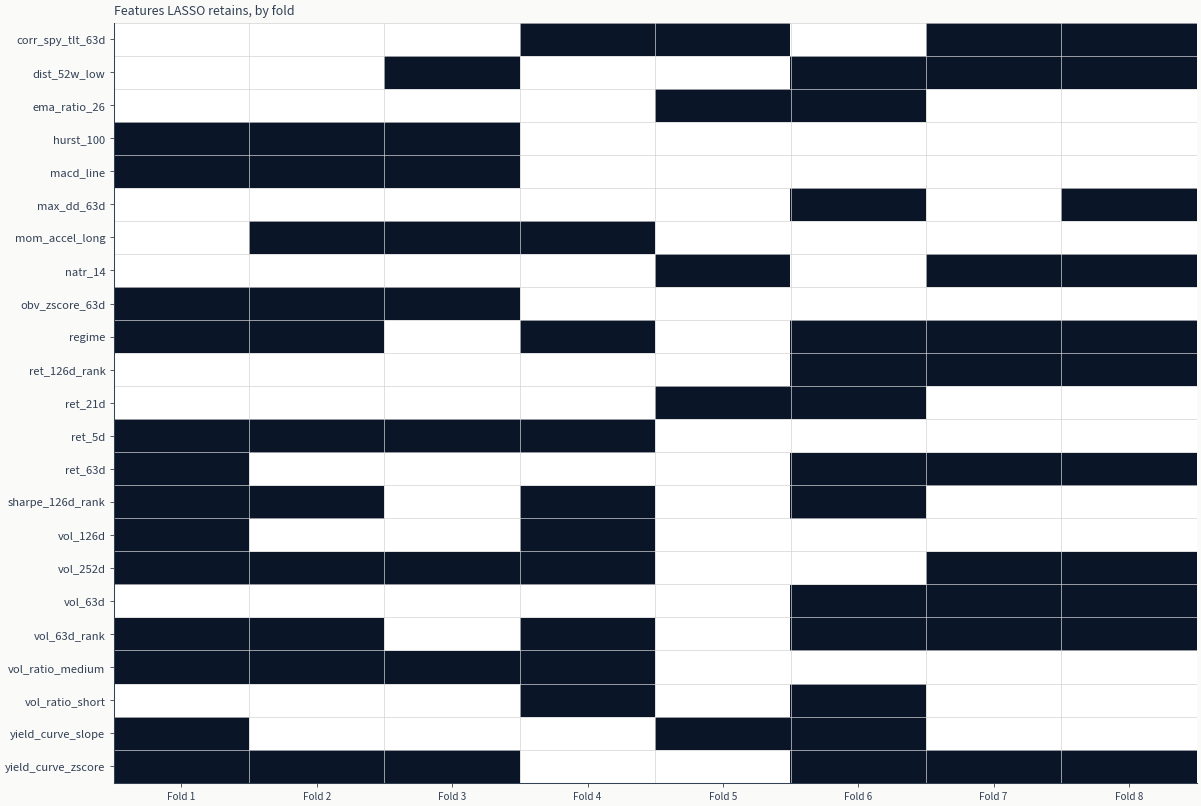

In [19]:
best_lasso_coeffs = lasso_all[best_lasso_alpha]["coeffs"]  # (n_folds, n_features)
nonzero_mask = (np.abs(best_lasso_coeffs) > 1e-8).astype(int)

# Show features that are nonzero in at least 2 folds (reduces clutter for print)
fold_count = nonzero_mask.sum(axis=0)
show_mask = fold_count >= 2
mask_subset = nonzero_mask[:, show_mask]
names_subset = [FEATURE_COLS[i] for i in range(len(FEATURE_COLS)) if show_mask[i]]

cmap_binary = ListedColormap(["white", COLORS["blue"]])  # white / dark navy

fig, ax = plt.subplots(figsize=(12, max(4, len(names_subset) * 0.35)))
ax.imshow(mask_subset.T, aspect="auto", cmap=cmap_binary, interpolation="nearest")
ax.set_xticks(range(mask_subset.shape[0]))
ax.set_xticklabels([f"Fold {i + 1}" for i in range(mask_subset.shape[0])])
ax.set_yticks(range(len(names_subset)))
ax.set_yticklabels(names_subset, fontsize=9)
ax.set_title("Features LASSO retains, by fold")

# Add grid lines between cells
for i in range(mask_subset.shape[1] + 1):
    ax.axhline(i - 0.5, color="lightgray", lw=0.5)
for j in range(mask_subset.shape[0] + 1):
    ax.axvline(j - 0.5, color="lightgray", lw=0.5)
show_with_alt(
    fig,
    "Grid with one row per feature and one column per fold, filled where LASSO "
    "gave that feature a non-zero coefficient on that fold.",
)

Features present in all folds represent robust LASSO selections. Features that
flicker on and off are unstable - their inclusion depends on which training
window the model sees. This motivates Elastic Net, which retains correlated
feature groups rather than picking one arbitrarily.

## Elastic Net (L1 + L2)

Elastic Net blends the two penalties, and `l1_ratio` sets the mix: at one it is
LASSO, at zero it is Ridge. Holding alpha at the value the LASSO sweep selected
and varying only the ratio isolates what the mix decides, which is how much
sparsity you get for a given total penalty.

In [20]:
if NEED_TRAINING:
    EN_RATIOS = [0.25, 0.50, 0.75]
    en_all = {}

    for ratio in EN_RATIOS:
        key = f"l1={ratio:.2f}"
        res, coeffs, models = cross_validate(
            ElasticNet,
            {
                "alpha": best_lasso_alpha,
                "l1_ratio": ratio,
                "random_state": RANDOM_SEED,
                "max_iter": 5000,
            },
        )
        en_all[key] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "models": models,
            "alpha": best_lasso_alpha,
            "l1_ratio": ratio,
        }

In [21]:
if NEED_TRAINING:
    en_summary = pl.DataFrame(
        [
            {
                "params": k,
                "mean_ic": d["results"]["ic"].mean(),
                "std_ic": d["results"]["ic"].std(),
                "n_nonzero": int((np.abs(d["coeffs"]).mean(axis=0) > 1e-8).sum())
                if d["coeffs"].size > 0
                else 0,
            }
            for k, d in en_all.items()
        ]
    ).sort("mean_ic", descending=True)

    # Filter NaN before selecting best EN key
    _en_valid = en_summary.filter(pl.col("mean_ic").is_not_nan())
    best_en_key = (
        _en_valid.row(0, named=True)["params"]
        if _en_valid.height > 0
        else en_summary.row(0, named=True)["params"]
    )

In [22]:
print("Elastic Net Summary:")
en_summary

Elastic Net Summary:


params,mean_ic,std_ic,n_nonzero
str,f64,f64,i64
"""l1=0.75""",0.047696,0.072117,35
"""l1=0.50""",0.040912,0.075782,42
"""l1=0.25""",0.034712,0.072606,48


Higher `l1_ratio` produces more sparsity, closer to LASSO; lower values retain
more features, closer to Ridge. Holding alpha fixed is what makes the row-to-row
difference readable, and it also means the mix has not been tuned against the
alpha. Joint optimization of both $\alpha$ and
`l1_ratio` is demonstrated in `04_nested_cv_hpo`.

## Loss Function Comparison

The section text discusses MSE, MAE, and Huber loss. `SGDRegressor` provides a
unified interface: all three accept an L2 penalty and `sample_weight`. Fitting
them at one alpha, on one set of folds, isolates the loss function as the only
thing that differs.

In [23]:
if NEED_TRAINING:
    # SGDRegressor alpha maps differently: divide by n_samples for comparable regularization
    n_sgd = len(cv_splits[0][0])
    sgd_alpha = best_ridge_alpha / n_sgd

    loss_configs = {
        "MSE (squared)": {"loss": "squared_error", "penalty": "l2", "alpha": sgd_alpha},
        "Huber": {"loss": "huber", "penalty": "l2", "alpha": sgd_alpha},
        "MAE (ε-insensitive)": {"loss": "epsilon_insensitive", "penalty": "l2", "alpha": sgd_alpha},
    }
    loss_results = {}
    for name, params in loss_configs.items():
        res, _, _ = cross_validate(
            SGDRegressor, {**params, "max_iter": 5000, "random_state": RANDOM_SEED}
        )
        loss_results[name] = pl.DataFrame(res)

    loss_comparison = pl.DataFrame(
        [
            {"Loss": name, "Mean IC": df["ic"].mean(), "Std IC": df["ic"].std()}
            for name, df in loss_results.items()
        ]
    ).sort("Mean IC", descending=True)

In [24]:
print("Loss Function Comparison (L2 penalty, same α):")
loss_comparison

Loss Function Comparison (L2 penalty, same α):


Loss,Mean IC,Std IC
str,f64,f64
"""MAE (ε-insensitive)""",0.069121,0.068786
"""Huber""",0.067551,0.059287
"""MSE (squared)""",0.065562,0.053086


The three losses differ in how much weight they give a large residual. Squared
error grows with the square of it, so one extreme return can move the fit more
than a hundred ordinary ones. Huber is quadratic for small residuals and linear
beyond a threshold, so an outlier still counts but stops dominating.
The epsilon-insensitive loss ignores residuals smaller than epsilon entirely
and is linear outside that band. Return distributions are heavy-tailed, which
is the condition under which that difference shows up in a ranking metric, and
it is why the case-study pipelines in Ch12 reach for LightGBM's Huber
objective.

Read the table for the ordering, not for the level. `SGDRegressor` optimizes
by stochastic gradient descent under a learning-rate schedule, so its ICs are
not comparable with the closed-form Ridge solution above even at the same
alpha; only the comparison between the three losses, fitted the same way on
the same folds, is meaningful here.

### LASSO Coefficient Path

We use `sklearn.linear_model.lasso_path` on the first fold for an efficient
warm-started coefficient path (much faster than refitting per alpha).

In [25]:
if NEED_TRAINING:
    tr0 = cv_splits[0][0]
    scaler_path = StandardScaler()
    X_path = scaler_path.fit_transform(features_array[tr0])
    y_path = target_array[tr0]
    path_alphas, path_coefs, _ = lasso_path(X_path, y_path, n_alphas=80, random_state=RANDOM_SEED)

### Save Cache

In [26]:
if NEED_TRAINING:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(
        {
            "ols_df": ols_df,
            "ols_coeffs": ols_coeffs,
            "ols_models": ols_models,
            "ridge_all": ridge_all,
            "ridge_summary": ridge_summary,
            "best_ridge_alpha": best_ridge_alpha,
            "RIDGE_ALPHAS": RIDGE_ALPHAS,
            "lasso_all": lasso_all,
            "lasso_summary": lasso_summary,
            "best_lasso_alpha": best_lasso_alpha,
            "alpha_max": alpha_max,
            "LASSO_ALPHAS": LASSO_ALPHAS,
            "en_all": en_all,
            "en_summary": en_summary,
            "best_en_key": best_en_key,
            "path_alphas": path_alphas,
            "path_coefs": path_coefs,
            "sample_weight_results": sample_weight_results,
            "loss_comparison": loss_comparison,
        },
        RESULTS_PATH,
    )
    print(f"Saved results to {RESULTS_PATH}")

## Model Comparison

Each method is summarized by its mean IC across the walk-forward folds and by
the standard deviation of that IC, which says how much the number depends on
which fold you look at.

One caveat governs the whole comparison, and it is the reason `04_nested_cv_hpo`
exists. The alpha for each penalized model was chosen by taking the highest mean
IC over these same validation folds, and the score reported here is that same
highest mean IC. A number picked as the maximum of a sweep is biased upward by
the picking: some of it is the penalty helping, and some of it is the luck of
whichever alpha happened to suit these folds. Nothing here is held back to
measure the difference, so read the chart as a comparison of methods under a
tuning budget, not as an estimate of what any of them would score on data
nobody selected on. Nested cross-validation, in `04_nested_cv_hpo`, is what
separates the two.

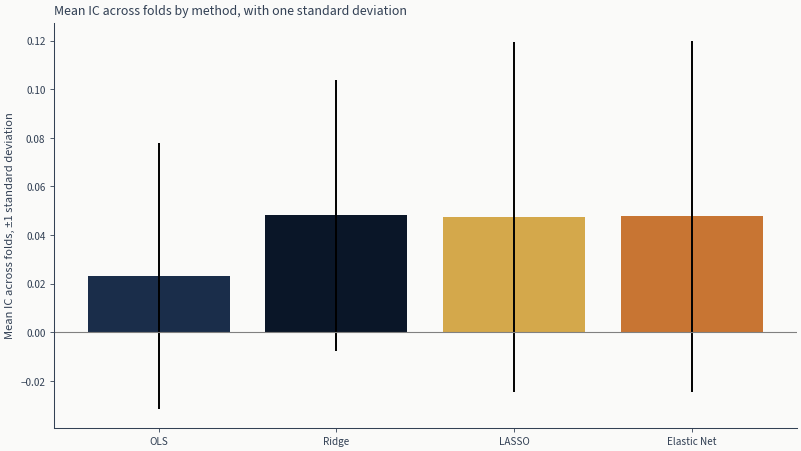

In [27]:
selected = {
    "OLS": ols_df,
    "Ridge": ridge_all[best_ridge_alpha]["results"],
    "LASSO": lasso_all[best_lasso_alpha]["results"],
    "Elastic Net": en_all[best_en_key]["results"],
}
model_ics = [frame["ic"].mean() for frame in selected.values()]
model_stds = [frame["ic"].std() for frame in selected.values()]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    np.arange(len(selected)),
    model_ics,
    yerr=model_stds,
    capsize=4,
    color=[COLORS["slate"], COLORS["blue"], COLORS["amber"], COLORS["copper"]],
)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xticks(np.arange(len(selected)))
ax.set_xticklabels(list(selected))
ax.set_ylabel("Mean IC across folds, ±1 standard deviation")
ax.set_title("Mean IC across folds by method, with one standard deviation")
show_with_alt(
    fig,
    "Bar chart of mean information coefficient for OLS, Ridge, LASSO and Elastic "
    "Net, each with an error bar one standard deviation wide.",
)

The error bars are wider than the gaps between the bars, which is worth seeing and is less
than it looks. Every method is scored on the same folds, so their scores rise and fall
together with whatever each fold happens to contain - and a method can be consistently
ahead of another while both have wide marginal spreads. Overlapping error bars across
methods do not settle whether one is ahead of another.

What settles it is the paired difference: subtract the two methods' IC fold by fold and
look at the spread of that series, which cancels the fold effect these bars are dominated
by. This chart shows the spread; it does not compare the methods.

### Prediction Rank Stability

How much do the model's cross-sectional rankings change between consecutive
folds? We apply both models (fold $t$ and fold $t+1$) to the same test set
and compute their Spearman rank correlation. High correlation means stable
rankings; low means the model learned fold-specific patterns.

In [28]:
best_ridge_data = ridge_all[best_ridge_alpha]
rank_corrs = []

for i in range(len(cv_splits) - 1):
    _, te_next = cv_splits[i + 1]
    X_te = features_array[te_next]
    m_curr = best_ridge_data["models"][i]
    m_next = best_ridge_data["models"][i + 1]
    pred_curr = m_curr["model"].predict(m_curr["scaler"].transform(X_te))
    pred_next = m_next["model"].predict(m_next["scaler"].transform(X_te))
    rc, _ = spearmanr(pred_curr, pred_next)
    rank_corrs.append(rc)

rank_corr_df = pl.DataFrame(
    {
        "Fold pair": [f"{i + 1}→{i + 2}" for i in range(len(rank_corrs))],
        "Spearman ρ": [round(rc, 4) for rc in rank_corrs],
    }
)
print(f"Mean rank correlation: {np.mean(rank_corrs):.4f}")
rank_corr_df

Mean rank correlation: 0.7149


Fold pair,Spearman ρ
str,f64
"""1→2""",0.9228
"""2→3""",0.6586
"""3→4""",0.7124
"""4→5""",0.3706
"""5→6""",0.5319
"""6→7""",0.8882
"""7→8""",0.9201


High rank correlation confirms that Ridge produces stable cross-sectional
rankings across folds - the same features rank near the top across folds
regardless of the training window. Lower values would indicate instability
and high implied turnover.

> **Turnover**: Rank stability is a proxy for signal turnover - the fraction
> of the portfolio that changes between rebalancing dates. The per-case-study
> runner notebooks (`06_linear.py`) compute explicit turnover alongside IC;
> Chapter 17 develops the full turnover-adjusted evaluation framework.
> `ml4t.diagnostic.signal.compute_turnover()` provides the production implementation.

## Regularization Paths

### What LASSO gives up as the penalty rises

Two things move together as $\alpha$ increases: the model keeps fewer
features, and its ranking accuracy changes. Plotting them on one axis shows
where dropping features stops being free. The two vertical scales are
different quantities, so each is labelled in the colour of its own series.

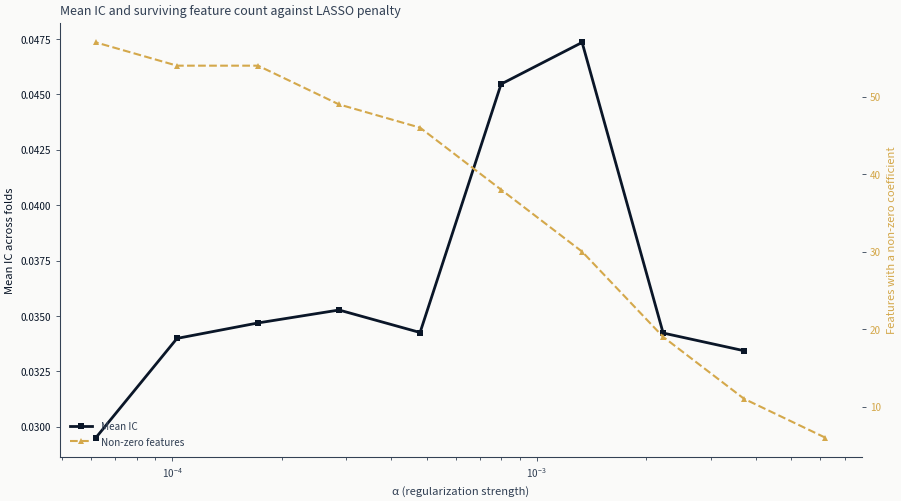

In [29]:
alphas_sorted = sorted(ridge_all.keys())
alphas_l = sorted(lasso_all.keys(), reverse=True)
ics_lasso = [lasso_all[a]["results"]["ic"].mean() for a in alphas_l]
nz_lasso = [int((np.abs(lasso_all[a]["coeffs"]).mean(axis=0) > 1e-8).sum()) for a in alphas_l]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(alphas_l, ics_lasso, "s-", color=COLORS["blue"], lw=2, label="Mean IC")
ax.set_xlabel("α (regularization strength)")
ax.set_ylabel("Mean IC across folds", color=COLORS["blue"])
ax.tick_params(axis="y", labelcolor=COLORS["blue"])

ax_nz = ax.twinx()
ax_nz.semilogx(alphas_l, nz_lasso, "^--", color=COLORS["amber"], lw=1.5, label="Non-zero features")
ax_nz.set_ylabel("Features with a non-zero coefficient", color=COLORS["amber"])
ax_nz.tick_params(axis="y", labelcolor=COLORS["amber"])

lines, labels = ax.get_legend_handles_labels()
lines_nz, labels_nz = ax_nz.get_legend_handles_labels()
ax.legend(lines + lines_nz, labels + labels_nz, loc="lower left", frameon=False)
ax.set_title("Mean IC and surviving feature count against LASSO penalty")
show_with_alt(
    fig,
    "Two series against regularization strength on a log axis: mean information "
    "coefficient on the left scale and the count of non-zero coefficients on the right.",
)

The two series come apart, and where they do is the point. The feature count falls away
over a range where mean validation IC does not, so across that range LASSO produces a
sparser model at no observed cost in ranking accuracy.

That is not the same as saying the dropped features carried nothing. Their coefficients
were non-zero and did contribute; what happens on refitting is that correlated features
take up the contribution. The chart shows the trade is available, not that it is free.

### LASSO Coefficient Path (Top 10 Features)

The coefficient path from `lasso_path` shows how features enter the model
as $\alpha$ decreases. We highlight only the 10 features with largest
peak magnitude to keep the plot readable.

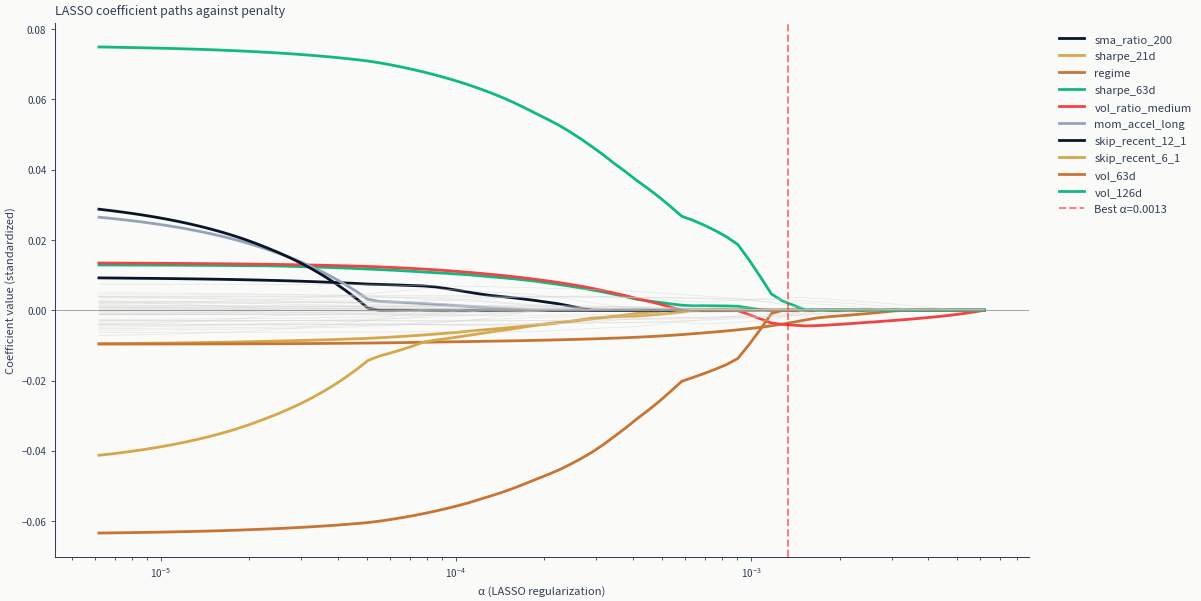

In [30]:
peak_coef = np.max(np.abs(path_coefs), axis=1)
top10_idx = np.argsort(peak_coef)[-10:]
top10_names = [FEATURE_COLS[i] for i in top10_idx]

fig, ax = plt.subplots(figsize=(12, 6))

for i in top10_idx:
    ax.semilogx(path_alphas, path_coefs[i], lw=2, label=FEATURE_COLS[i])

for i in range(path_coefs.shape[0]):
    if i not in top10_idx:
        ax.semilogx(path_alphas, path_coefs[i], lw=0.5, color="lightgray", alpha=0.5)

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(
    best_lasso_alpha, ls="--", color="red", alpha=0.5, label=f"Best α={best_lasso_alpha:.4f}"
)
ax.set_xlabel("α (LASSO regularization)")
ax.set_ylabel("Coefficient value (standardized)")
ax.set_title("LASSO coefficient paths against penalty")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
show_with_alt(
    fig,
    "Coefficient values against the LASSO penalty on a log axis. The ten largest paths "
    "are drawn in colour and the rest in grey, with a vertical marker at the selected "
    "alpha. The coloured paths reach zero at different penalties rather than together.",
)

### Ridge IC and ICIR vs Alpha

The extended alpha grid reveals the full regularization landscape: a flat zone
where Ridge matches OLS, an improving zone where shrinkage helps, and an
over-regularized zone where coefficients are crushed too aggressively.

In [31]:
alphas_sorted_full = sorted(ridge_all.keys())
ics_full = np.array([ridge_all[a]["results"]["ic"].mean() for a in alphas_sorted_full])
stds_full = np.array([ridge_all[a]["results"]["ic"].std() for a in alphas_sorted_full])
icirs_full = ics_full / np.where(stds_full > 0, stds_full, np.nan)

ols_ic = ols_df["ic"].mean()
ols_std = ols_df["ic"].std()
ols_icir = ols_ic / ols_std if ols_std > 0 else 0

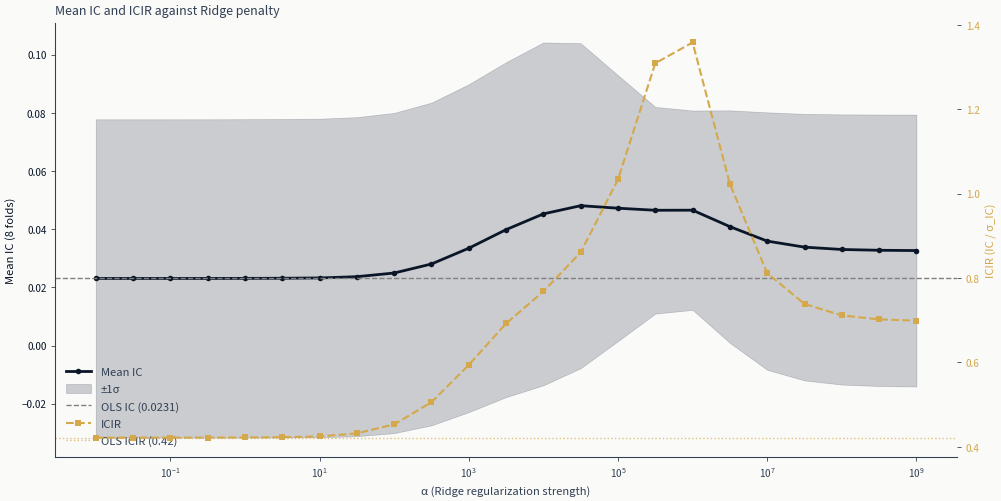

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# IC with ±1σ band
ax1.semilogx(alphas_sorted_full, ics_full, "o-", color=COLORS["blue"], lw=2, ms=4, label="Mean IC")
ax1.fill_between(
    alphas_sorted_full,
    ics_full - stds_full,
    ics_full + stds_full,
    alpha=0.2,
    color=COLORS["blue"],
    label="±1σ",
)
ax1.axhline(ols_ic, ls="--", color="gray", lw=1, label=f"OLS IC ({ols_ic:.4f})")
ax1.set_xlabel("α (Ridge regularization strength)")
ax1.set_ylabel("Mean IC (8 folds)", color=COLORS["blue"])
ax1.tick_params(axis="y", labelcolor=COLORS["blue"])

# ICIR on secondary axis
ax2 = ax1.twinx()
ax2.semilogx(
    alphas_sorted_full, icirs_full, "s--", color=COLORS["amber"], lw=1.5, ms=4, label="ICIR"
)
ax2.axhline(
    ols_icir, ls=":", color=COLORS["amber"], lw=1, alpha=0.7, label=f"OLS ICIR ({ols_icir:.2f})"
)
ax2.set_ylabel("ICIR (IC / σ_IC)", color=COLORS["amber"])
ax2.tick_params(axis="y", labelcolor=COLORS["amber"])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=9)

ax1.set_title("Mean IC and ICIR against Ridge penalty")
show_with_alt(
    fig,
    "Mean information coefficient with a one-standard-deviation band and the "
    "IC information ratio, both against Ridge regularization strength on a log axis.",
)

### Ridge IC/ICIR Statistics

Key statistics from the regularization sweep.

In [33]:
best_idx = np.argmax(icirs_full)
best_alpha = alphas_sorted_full[best_idx]
best_icir = icirs_full[best_idx]
best_ic = ics_full[best_idx]
best_std = stds_full[best_idx]
n_samples = sum(len(tr) + len(te) for tr, te in cv_splits)

print("=== Ridge IC/ICIR Statistics ===")
print(
    f"Alpha range: {alphas_sorted_full[0]:.0e} to {alphas_sorted_full[-1]:.0e} ({len(alphas_sorted_full)} values)"
)
print(f"Total sample size: {df.height:,}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"OLS baseline: IC={ols_ic:.4f}, std={ols_std:.4f}, ICIR={ols_icir:.2f}")
print(f"Best ICIR: {best_icir:.2f} at α={best_alpha:.0e}")
print(f"  Mean IC: {best_ic:.4f}, Std IC: {best_std:.4f}")
print(f"  IC improvement: {(best_ic - ols_ic) / abs(ols_ic) * 100:.0f}%")
print(f"  Std reduction: {(1 - best_std / ols_std) * 100:.0f}%")
print(f"  ICIR improvement: {best_icir / ols_icir:.1f}x over OLS ({ols_icir:.2f})")

=== Ridge IC/ICIR Statistics ===
Alpha range: 1e-02 to 1e+09 (23 values)
Total sample size: 402,446
Features: 57
OLS baseline: IC=0.0231, std=0.0547, ICIR=0.42
Best ICIR: 1.36 at α=1e+06
  Mean IC: 0.0466, Std IC: 0.0343
  IC improvement: 102%
  Std reduction: 37%
  ICIR improvement: 3.2x over OLS (0.42)


### Ridge Coefficient Path

The same sweep read through the coefficients rather than the score. Every
feature keeps a non-zero weight at every alpha, and the weights shrink towards
zero together as the penalty rises. That is the difference from the LASSO path
above, where features leave the model one at a time and do not come back.

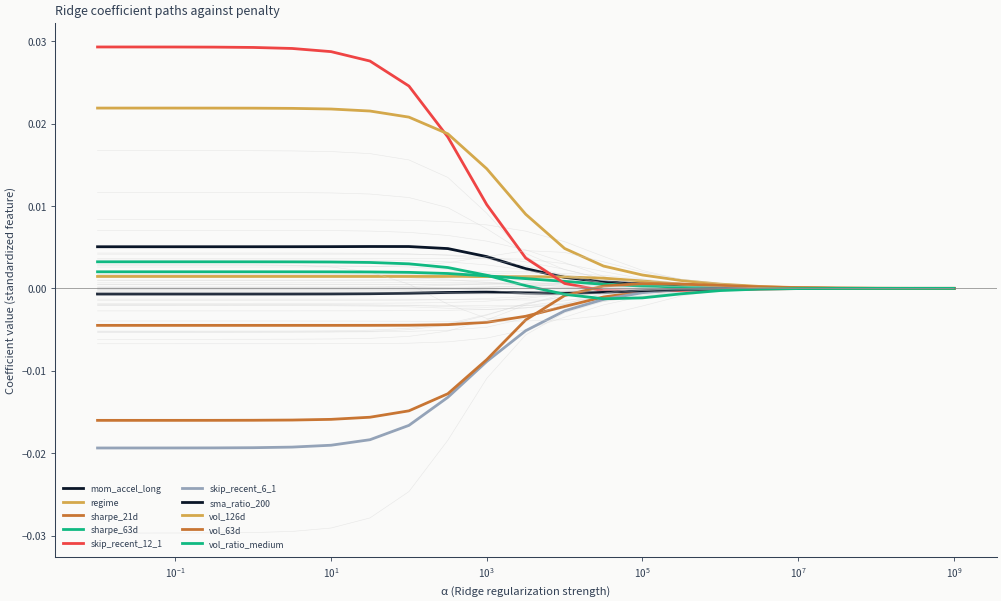

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
for j, feat in enumerate(FEATURE_COLS):
    coefs_by_alpha = [ridge_all[a]["coeffs"].mean(axis=0)[j] for a in alphas_sorted]
    if feat in top10_names:
        ax.semilogx(alphas_sorted, coefs_by_alpha, lw=2, label=feat)
    else:
        ax.semilogx(alphas_sorted, coefs_by_alpha, lw=0.4, color="lightgray", alpha=0.5)
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("α (Ridge regularization strength)")
ax.set_ylabel("Coefficient value (standardized feature)")
ax.set_title("Ridge coefficient paths against penalty")
ax.legend(fontsize=7, loc="lower left", ncol=2, frameon=False)
show_with_alt(
    fig,
    "Coefficient values against regularization strength on a log axis, one line "
    "per feature, all converging towards zero as the penalty rises.",
)

Compare this against the LASSO paths above. Ridge pulls every coefficient toward zero and
leaves all of them non-zero; LASSO sets them to exactly zero one at a time. That difference
is the reason to reach for one or the other: LASSO answers which features to keep, Ridge
answers how much to believe all of them.

The two coefficient paths are the whole difference between the penalties in
one picture. Ridge attenuates every weight and keeps every feature; LASSO
removes features one at a time, and which ones it removes depends on the
training window. Elastic Net sits between them: it can zero a coefficient, but
its L2 component keeps correlated features together rather than picking one of
the group arbitrarily.

## Key Takeaways

1. **Shrinkage buys variance reduction with bias.** Ridge pulls every
   coefficient towards zero, which costs accuracy on the training fold and can
   repay it on the next one. Where features are many, correlated, and weakly
   related to the target, that trade is usually worth making, and the alpha
   sweep is how you find out where it stops paying.

2. **LASSO performs feature selection**: at the selected alpha some
   coefficients are exactly zero and those features leave the model. The
   coefficient path shows the order in which the rest enter as the penalty
   weakens, and the fold heatmap shows how much of that selection is repeated
   when the training window changes.

3. **Elastic Net** blends both penalties. Higher L1 ratio produces more
   sparsity; the choice depends on whether you value interpretability or
   want to retain correlated features.

4. **Walk-forward CV with purging** is what makes any of these numbers
   meaningful. Standard K-fold trains on data that follows its test window and
   scores a model against outcomes it has already seen, and with a 21-day
   forward label the fold boundary has to be widened by the label horizon
   before the two sides are genuinely separate.

**Next**: See `03_logistic_classification` for direction prediction, or
`04_nested_cv_hpo` for hyperparameter optimization with Optuna.